# EDA: Who Owns
This EDA examines who owns residential property in Switzerland across generations:

* Silent Generation (<=1945)
* Babyboomers (1946-1964)
* Generation X (1965-1980)
* Millennials / Gen Y (1981-1996)
* Generation Z (1997-2012)

Data basis: four FSO (Federal Statistical Office) sources (2019–2024).

**Key Research Questions**

| # | Question |
|---|----------|
| 1 | Which generations dominate the Swiss population, and is this changing? |
| 2 | How much does the homeownership rate vary between cantons? (optional) |
| 3 | Which occupancy type dominates within each generation? |
| 4 | Do older generations have more living space per person? |
| 5 | Is the cantonal homeownership rate correlated with the share of older residents? |

## Imports & Configuration

In [55]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Visual setup ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

# ── Configuration ─────────────────────────────────────────────
GEN_ORDER = [
    "Silent Generation (<=1945)",
    "Babyboomers (1946-1964)",
    "Generation X (1965-1980)",
    "Millennials / Gen Y (1981-1996)",
    "Generation Z (1997-2012)",
    "Ausserhalb Definition",
]
GEN_ORDER_PLOT = GEN_ORDER[:-1]          # without "Outside definition"
GEN_PALETTE    = dict(zip(GEN_ORDER_PLOT, sns.color_palette("tab10", n_colors=len(GEN_ORDER_PLOT))))

# Occupancy type colors
BT_PALETTE = {
    "Eigentuemer":                "#2a9d8f",
    "Mieter / Genossenschafter":  "#e76f51",
    "Andere Situation":           "#e9c46a",
}


## Helper Functions

In [56]:
def find_project_root(start: Path) -> Path:
    """Find the project directory (first directory containing a data/ folder)."""
    for p in [start, *start.parents]:
        if (p / "data").exists():
            return p
    raise FileNotFoundError("No project directory with data/ found.")


def find_col(df: pd.DataFrame, *keywords: str) -> str | None:
    """Return the first column name that contains all keywords (case-insensitive)."""
    kws = [k.lower() for k in keywords]
    for col in df.columns:
        if all(k in col.lower() for k in kws):
            return col
    return None


def normalize_year(df: pd.DataFrame) -> pd.Series:
    """Read the year column (time_period / jahr / year) as integers."""
    col = find_col(df, "time_period") or find_col(df, "jahr") or find_col(df, "year")
    if col:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series([pd.NA] * len(df), dtype="Int64")


def generation_from_birth_year(birth_year: float) -> str:
    """Assign a generation label based on the birth year."""
    if pd.isna(birth_year):
        return "Ausserhalb Definition"
    by = int(birth_year)
    if by <= 1945:   return "Silent Generation (<=1945)"
    if by <= 1964:   return "Babyboomers (1946-1964)"
    if by <= 1980:   return "Generation X (1965-1980)"
    if by <= 1996:   return "Millennials / Gen Y (1981-1996)"
    if by <= 2012:   return "Generation Z (1997-2012)"
    return "Ausserhalb Definition"


def add_generation(df: pd.DataFrame, year_col: str, age_col: str) -> pd.DataFrame:
    """Compute birth year and generation label in-place and return df."""
    df = df.copy()
    df["birth_year"]       = pd.to_numeric(df[year_col], errors="coerce") - pd.to_numeric(df[age_col], errors="coerce")
    df["generation_label"] = df["birth_year"].apply(generation_from_birth_year)
    df["generation_label"] = pd.Categorical(df["generation_label"], categories=GEN_ORDER, ordered=True)
    return df


def normalize_bewohnertyp(value: str) -> str:
    """Standardize occupancy-type labels."""
    t = str(value).strip().lower()
    if "eigent"  in t:                  return "Eigentuemer"
    if "mieter"  in t or "genoss" in t: return "Mieter / Genossenschafter"
    if "andere"  in t:                  return "Andere Situation"
    return str(value).strip()


## Load Data

**Sources (FSO)**

| Variable | File |
|---|---|
| `wohneigentum` | Homeownership rate by canton |
| `wohnflaeche` | Living space per person by age & year |
| `bewohnertyp` | Occupancy type (owner/tenant/other) by age & year |
| `demo_raw` | Demographic balance (population by canton, age, year) |


In [57]:
BASE = find_project_root(Path.cwd())
DATA = BASE / "data" / "whoOwns" / "processed"

wohneigentum = pd.read_csv(DATA / "wohneigentumsquote_kanton_2026_clean.csv")
wohnflaeche  = pd.read_csv(DATA / "bfs_wohnflaeche_20260414_clean.csv")
bewohnertyp  = pd.read_csv(DATA / "bfs_bewohnertyp_20260414_clean.csv")
demo_raw     = pd.read_csv(
    BASE / "data" / "demografischeBilanz.csv",
    sep=";", encoding="latin1"
)

# Overview
for name, df in [("wohneigentum", wohneigentum), ("wohnflaeche", wohnflaeche),
                 ("bewohnertyp", bewohnertyp), ("demo_raw", demo_raw)]:
    print(f"{name:20s}  {df.shape[0]:>6} rows × {df.shape[1]:>2} columns")


wohneigentum             162 rows × 10 columns
wohnflaeche              600 rows ×  5 columns
bewohnertyp             2040 rows × 10 columns
demo_raw              154224 rows ×  7 columns


In [58]:
# Data overview: homeownership data
print("\n" + "="*70)
print("DATA OVERVIEW: Homeownership Data (Cantonal)")
print("="*70)
print(f"\nDataset shape: {wohneigentum.shape[0]} rows × {wohneigentum.shape[1]} columns")
print(f"\nAvailable columns:\n{list(wohneigentum.columns)}")
print(f"\nMissing values:\n{wohneigentum.isnull().sum()[wohneigentum.isnull().sum() > 0]}")
print(f"\nData types:\n{wohneigentum.dtypes}")

# Show preview
print("\nPreview (first 5 rows):")
# wohneigentum.head()

wohneigentum.drop(columns=['geo', 'obs_status'], errors='ignore', inplace=True)
wohneigentum.head()


DATA OVERVIEW: Homeownership Data (Cantonal)

Dataset shape: 162 rows × 10 columns

Available columns:
['time_period', 'geo', 'obs_value', 'obs_confidence', 'obs_status', 'code', 'label_en', 'label_fr', 'label_de', 'label_it']

Missing values:
Series([], dtype: int64)

Data types:
time_period         int64
geo                object
obs_value         float64
obs_confidence    float64
obs_status         object
code               object
label_en           object
label_fr           object
label_de           object
label_it           object
dtype: object

Preview (first 5 rows):


,time_period,obs_value,obs_confidence,code,label_en,label_fr,label_de,label_it
0,2019,27.7,0.5,CH040,Zürich,Zurich,Zürich,Zurigo
1,2019,38.8,0.6,CH021,Bern,Berne,Bern,Berna
2,2019,34.4,0.7,CH061,Luzern,Lucerne,Luzern,Lucerna
3,2019,42.9,3.5,CH062,Uri,Uri,Uri,Uri
4,2019,39.4,1.6,CH063,Schwyz,Schwyz,Schwyz,Svitto


In [59]:
# Data overview: occupancy-type data
print("\n" + "="*70)
print("OCCUPANCY-TYPE ANALYSIS (FSO)")
print("="*70)
print(f"\nShape: {bewohnertyp.shape}")
print(f"\nColumns: {list(bewohnertyp.columns)}")
print(f"\nMissing values per column:")
print(bewohnertyp.isnull().sum())

print(f"\nSample data:")
bewohnertyp.head()


OCCUPANCY-TYPE ANALYSIS (FSO)

Shape: (2040, 10)

Columns: ['alter', 'bewohnertyp', 'absolute zahlen', 'vertrauens-intervall : \n± (in %)', 'anteil in %', 'vertrauens-\nintervall : \n± (in %-pkte)', 'datenqualität', 'time_period', 'source_sheet', 'sheet_type']

Missing values per column:
alter                                          0
bewohnertyp                                    0
absolute zahlen                                8
vertrauens-intervall : \n± (in %)              9
anteil in %                                    7
vertrauens-\nintervall : \n± (in %-pkte)     517
datenqualität                               1916
time_period                                    0
source_sheet                                   0
sheet_type                                     0
dtype: int64

Sample data:


,alter,bewohnertyp,absolute zahlen,vertrauens-intervall : \n± (in %),anteil in %,vertrauens-\nintervall : \n± (in %-pkte),datenqualität,time_period,source_sheet,sheet_type
0,15,Mieter oder Genossenschafter,40110.0,6.2,46.0,2.0,NaN,2024,SE2024,bewohnertyp
1,15,Eigentümer,41551.0,5.6,47.7,2.0,NaN,2024,SE2024,bewohnertyp
2,15,Andere Situation2),5534.0,17.1,6.3,1.0,NaN,2024,SE2024,bewohnertyp
3,15,Total,87196.0,4.0,100.0,NaN,NaN,2024,SE2024,bewohnertyp
4,16,Mieter oder Genossenschafter,41074.0,6.5,47.0,2.1,NaN,2024,SE2024,bewohnertyp


In [60]:
# Data overview: living-space distribution
print("\n" + "="*70)
print("LIVING-SPACE DISTRIBUTION (FSO)")
print("="*70)
print(f"\nShape: {wohnflaeche.shape}")
print(f"\nColumns: {list(wohnflaeche.columns)}")
print(f"\nMissing values per column:")
print(wohnflaeche.isnull().sum())

print(f"\nSample data:")
wohnflaeche.head()


LIVING-SPACE DISTRIBUTION (FSO)

Shape: (600, 5)

Columns: ['alter', 'wohnfläche (in m2) pro person', 'time_period', 'source_sheet', 'sheet_type']

Missing values per column:
alter                            0
wohnfläche (in m2) pro person    0
time_period                      0
source_sheet                     0
sheet_type                       0
dtype: int64

Sample data:


,alter,wohnfläche (in m2) pro person,time_period,source_sheet,sheet_type
0,0,27.6,2024,GWS-STATPOP2024,wohnflaeche
1,1,28.3,2024,GWS-STATPOP2024,wohnflaeche
2,2,28.2,2024,GWS-STATPOP2024,wohnflaeche
3,3,28.1,2024,GWS-STATPOP2024,wohnflaeche
4,4,27.9,2024,GWS-STATPOP2024,wohnflaeche


## Data Preparation

In [61]:
# ── 3a Demographic balance ─────────────────────────────────────────────────────
demo = demo_raw.copy()
demo.columns = demo.columns.str.strip()

year_col   = find_col(demo, "jahr")
canton_col = find_col(demo, "kanton")
age_col    = find_col(demo, "alter")
nat_col    = find_col(demo, "staatsange")
gender_col = find_col(demo, "geschlecht")
pop_col    = find_col(demo, "31") or find_col(demo, "dez")

# Keep totals only (nationality & gender)
for col, keyword in [(nat_col, "total"), (gender_col, "total")]:
    if col:
        demo = demo[demo[col].astype(str).str.contains(keyword, case=False, na=False)]

demo["year"]       = pd.to_numeric(demo[year_col], errors="coerce").astype("Int64")
demo["population"] = pd.to_numeric(demo[pop_col],  errors="coerce")
demo["age_num"]    = pd.to_numeric(
    demo[age_col].astype(str).str.extract(r"(\d+)", expand=False), errors="coerce"
)
demo = demo.dropna(subset=["year", "age_num", "population"]).copy()
demo = add_generation(demo, year_col="year", age_col="age_num")

# ── 3b Living space ────────────────────────────────────────────────────────────
wf_age_col  = find_col(wohnflaeche, "alter")
wf_area_col = find_col(wohnflaeche, "wohnfläche", "person") or find_col(wohnflaeche, "wohnflaeche", "person")
wohnflaeche["time_period"] = normalize_year(wohnflaeche).astype("Int64")
wohnflaeche = wohnflaeche.dropna(subset=[wf_age_col, "time_period"]).copy()
wohnflaeche = add_generation(wohnflaeche, year_col="time_period", age_col=wf_age_col)

# ── 3c Occupancy type ──────────────────────────────────────────────────────────
bt_age_col  = find_col(bewohnertyp, "alter")
bt_cat_col  = find_col(bewohnertyp, "bewohnertyp")
bt_val_col  = find_col(bewohnertyp, "absolute") or find_col(bewohnertyp, "anzahl")
bewohnertyp["time_period"] = normalize_year(bewohnertyp).astype("Int64")
bewohnertyp = bewohnertyp.dropna(subset=[bt_age_col, "time_period"]).copy()
bewohnertyp = add_generation(bewohnertyp, year_col="time_period", age_col=bt_age_col)
bewohnertyp["bt_label"] = bewohnertyp[bt_cat_col].apply(normalize_bewohnertyp)

# ── 3d Homeownership (canton) ──────────────────────────────────────────────────
wohneigentum.drop(columns=["geo", "obs_status"], errors="ignore", inplace=True)
we_kantone = wohneigentum[
    wohneigentum["label_de"].notna() &
    ~wohneigentum["label_de"].str.lower().isin(["schweiz", "ohne angabe"])
].copy()

print("Data preparation complete.")
print(f"  demo:          {demo.shape}")
print(f"  wohnflaeche:   {wohnflaeche.shape}")
print(f"  bewohnertyp:   {bewohnertyp.shape}")
print(f"  we_kantone:    {we_kantone.shape}")


Data preparation complete.
  demo:          (16800, 12)
  wohnflaeche:   (600, 7)
  bewohnertyp:   (2040, 13)
  we_kantone:    (156, 8)


## Analysis 1 – Generation Shares in Switzerland (2019–2024)

**Expected pattern:** The Silent Generation shrinks due to mortality, Babyboomers remain the largest group, Millennials and Gen Z grow slightly.


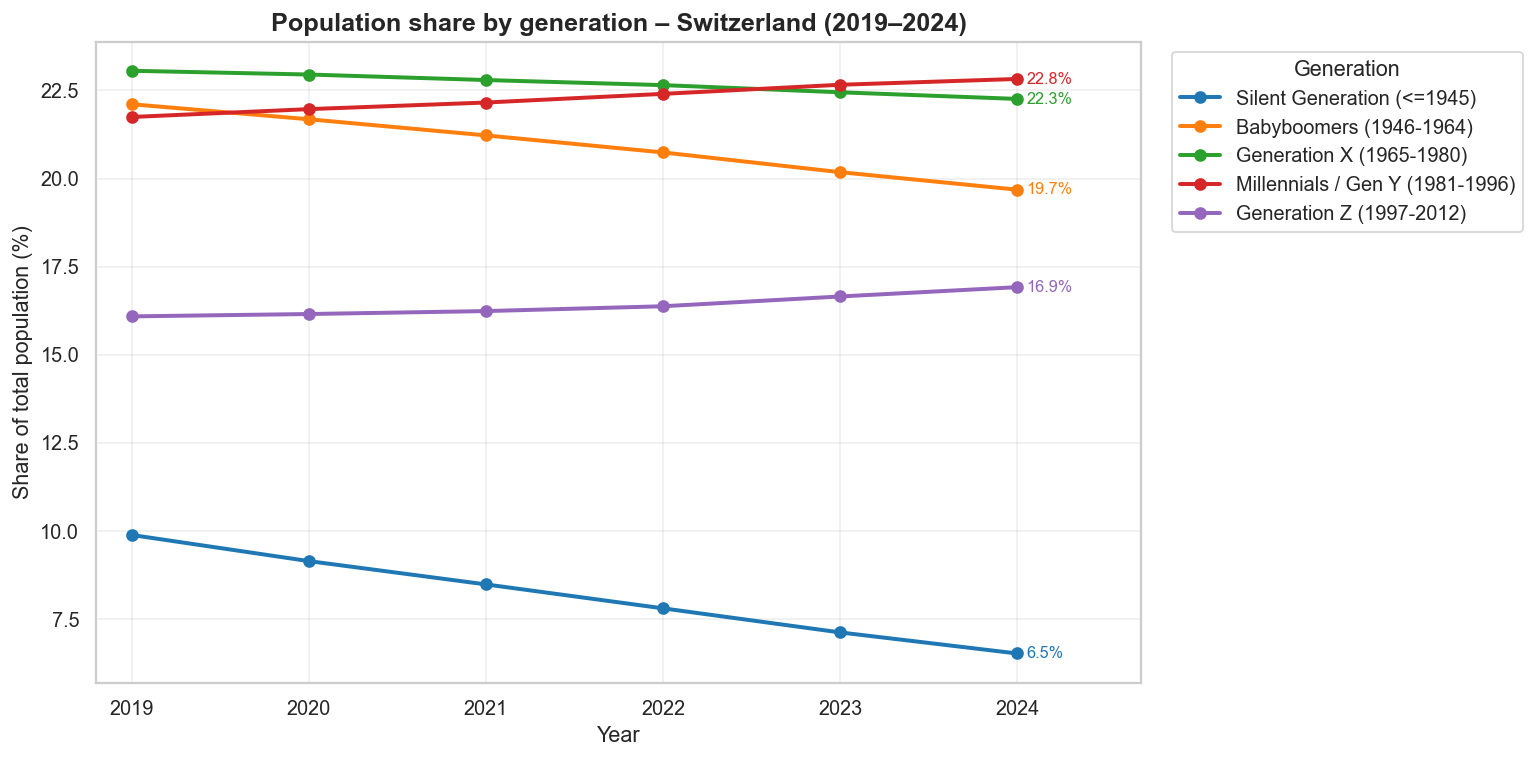


Change in generation shares 2019 → 2024:
year                              2019   2024  Δ (pp)
generation_label                                     
Silent Generation (<=1945)        9.88   6.52   -3.36
Babyboomers (1946-1964)          22.11  19.68   -2.43
Generation X (1965-1980)         23.06  22.26   -0.80
Millennials / Gen Y (1981-1996)  21.75  22.83    1.08
Generation Z (1997-2012)         16.09  16.92    0.83


In [62]:
# ── Aggregation ────────────────────────────────────────────────────────────────
schweiz = demo[
    demo[canton_col].astype(str).str.strip().str.lower() == "schweiz"
].copy()

gen_year = (
    schweiz
    .groupby(["year", "generation_label"], observed=False)["population"]
    .sum()
    .reset_index()
)
gen_year["share_pct"] = (
    gen_year.groupby("year")["population"]
    .transform(lambda s: s / s.sum() * 100 if s.sum() > 0 else 0)
)
gen_year = gen_year[gen_year["generation_label"].isin(GEN_ORDER_PLOT)]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for gen in GEN_ORDER_PLOT:
    sub = gen_year[gen_year["generation_label"] == gen].sort_values("year")
    if sub.empty:
        continue
    color = GEN_PALETTE[gen]
    ax.plot(sub["year"], sub["share_pct"], marker="o", linewidth=2.2, color=color, label=gen)
    last = sub.iloc[-1]
    ax.annotate(f"{last['share_pct']:.1f}%", xy=(last["year"], last["share_pct"]),
                xytext=(5, 0), textcoords="offset points", va="center", fontsize=9, color=color)

years_all = sorted(gen_year["year"].unique())
ax.set_xticks(years_all)
ax.set_xlim(years_all[0] - 0.2, years_all[-1] + 0.7)
ax.set_title("Population share by generation – Switzerland (2019–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Share of total population (%)", fontsize=12)
ax.legend(title="Generation", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Comparison table ───────────────────────────────────────────────────────────
pivot = (
    gen_year[gen_year["year"].isin([2019, 2024])]
    .pivot(index="generation_label", columns="year", values="share_pct")
)
pivot["Δ (pp)"] = pivot[2024] - pivot[2019]
print("\nChange in generation shares 2019 → 2024:")
print(pivot.round(2).to_string())


### Interpretation (Analysis 1)

**Key takeaway**
Babyboomers and Generation X remain the largest cohorts, while the Silent Generation declines over time and younger cohorts increase slightly.

**What this means**
The demographic structure is shifting gradually, not abruptly. This supports a long-term generational transition rather than a short-term break.

**Caveat**
These are aggregate shares at the national level. They do not show within-generation differences by income, canton, or migration background.

## Analysis 2 – Population by Canton

Zurich, Bern, and Vaud together make up about 40% of the Swiss population. These size differences should be kept in mind when reading cantonal homeownership rates.


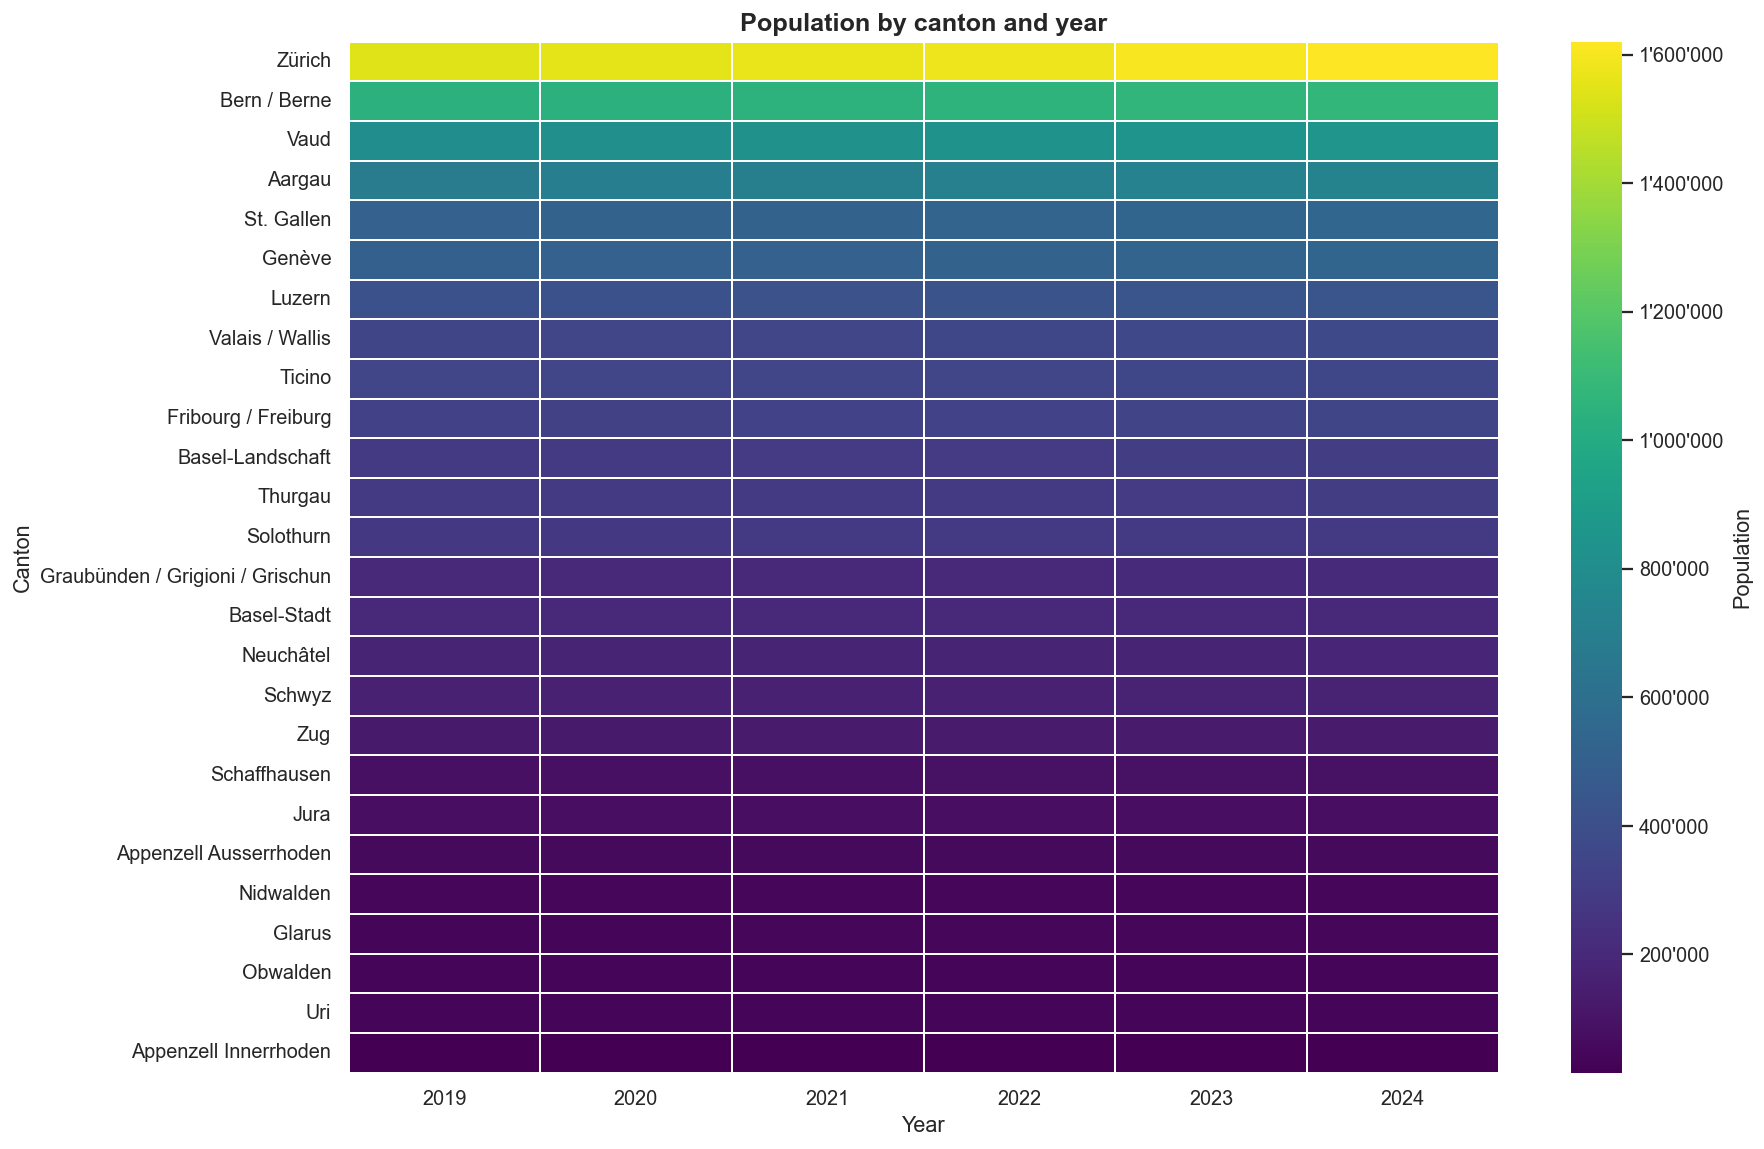

In [63]:
kanton_year = (
    demo[~demo[canton_col].astype(str).str.strip().str.lower().isin(["schweiz", "ohne angabe"])]
    .groupby([canton_col, "year"], as_index=False)["population"]
    .sum()
)

kanton_order = (
    kanton_year.groupby(canton_col)["population"]
    .sum().sort_values(ascending=False).index.tolist()
)
heatmap_data = (
    kanton_year
    .pivot(index=canton_col, columns="year", values="population")
    .reindex(kanton_order)
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    heatmap_data, ax=ax, cmap="viridis",
    linewidths=0.2, linecolor="white",
    cbar_kws={"label": "Population"},
    fmt=".0f"
)
# Thousand separators on colorbar
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "'"))
)
ax.set_title("Population by canton and year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Canton", fontsize=12)
plt.tight_layout()
plt.show()


### Interpretation (Analysis 2)

**Key takeaway**
Population is highly concentrated in a few cantons (especially Zurich, Bern, and Vaud), while many cantons are much smaller.

**What this means**
Cross-cantonal comparisons of homeownership should be interpreted with scale in mind: similar percentages can represent very different numbers of people.

**Caveat**
This heatmap shows population levels, not housing-market pressure, affordability, or tenure dynamics directly.

## Analysis 3 – Homeownership Rate by Canton

Clear **urban-rural gradient**: Geneva ~18% vs. Uri/Appenzell >55%.  
The reference line shows the unweighted Swiss average across all available years.


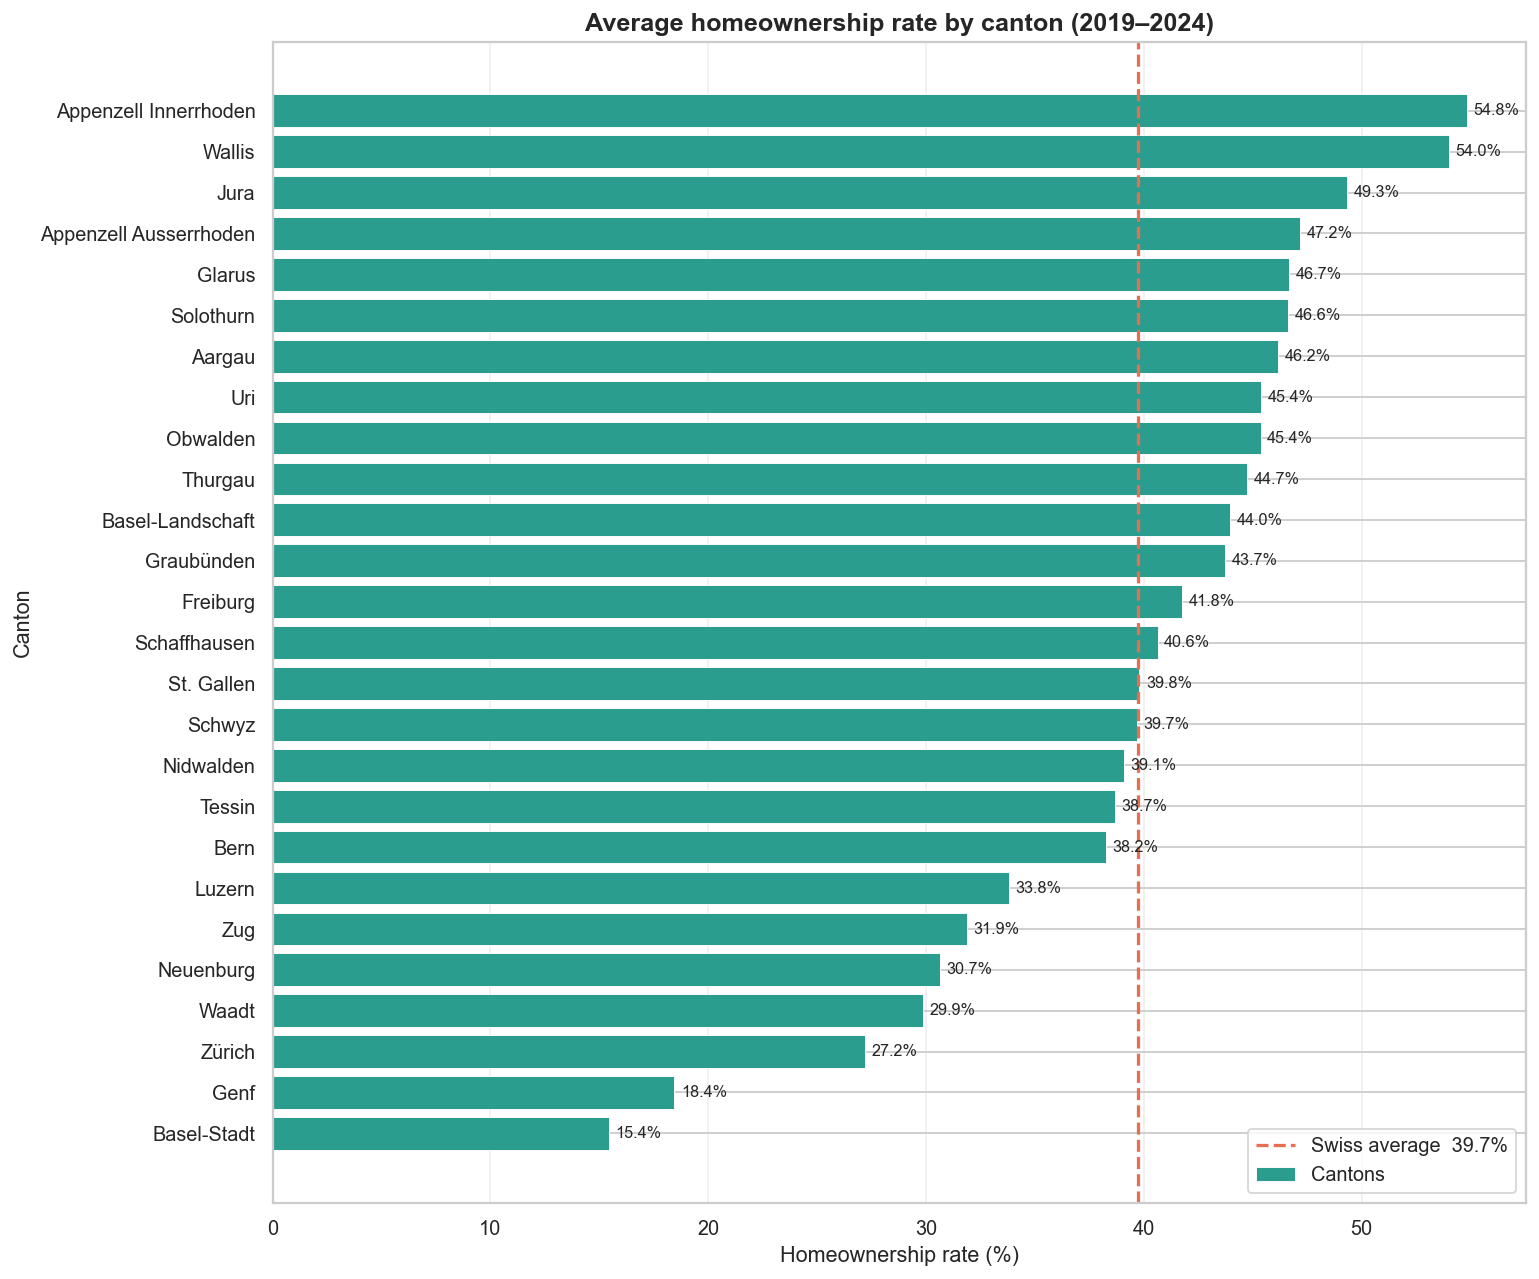

  Min: 15.4%  (Basel-Stadt)
  Max: 54.8%  (Appenzell Innerrhoden)


C:\Users\jmart\AppData\Local\Temp\ipykernel_38868\3209700507.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (


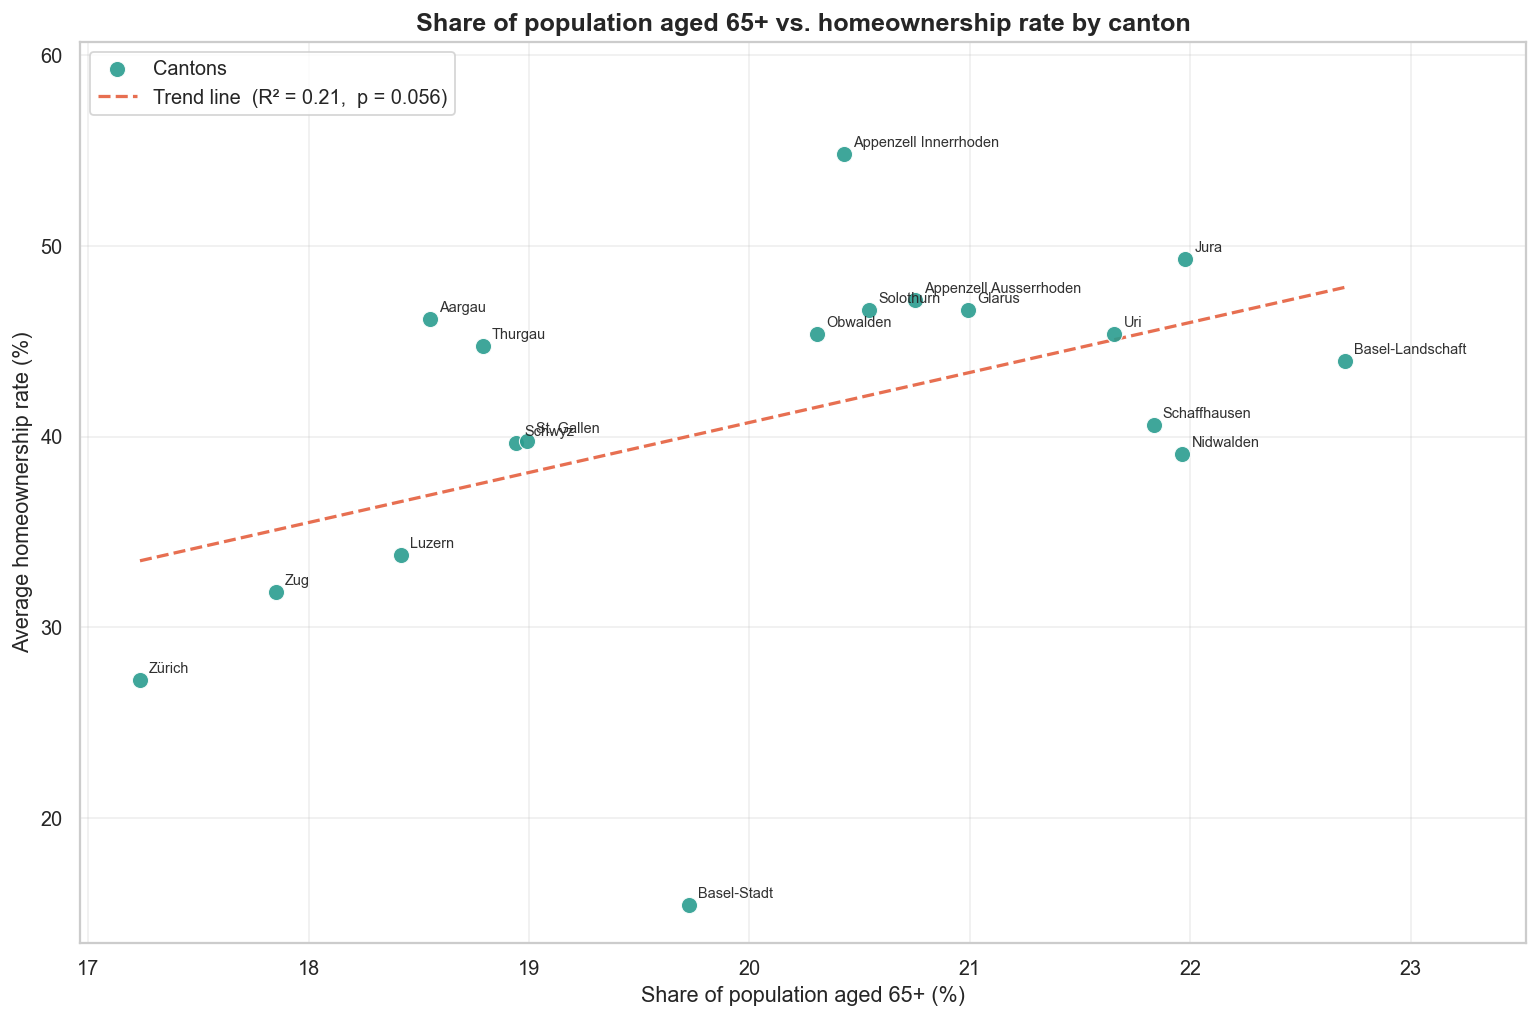

Pearson r = 0.458  |  R² = 0.210  |  p = 0.0561
→ Not significant

Top 10 cantons by homeownership rate:
                canton  homeownership_pct  pct_65plus
 Appenzell Innerrhoden              54.82       20.43
                  Jura              49.32       21.98
Appenzell Ausserrhoden              47.18       20.75
                Glarus              46.67       20.99
             Solothurn              46.63       20.54
                Aargau              46.17       18.55
                   Uri              45.40       21.66
              Obwalden              45.37       20.31
               Thurgau              44.73       18.79
      Basel-Landschaft              43.97       22.70


In [64]:
ranking = (
    we_kantone.groupby("label_de")["obs_value"]
    .mean().sort_values(ascending=True).reset_index()
)
ch_avg = ranking["obs_value"].mean()

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(ranking["label_de"], ranking["obs_value"],
               color="#2a9d8f", edgecolor="white", linewidth=0.5, label="Cantons")
ax.axvline(ch_avg, color="#e76f51", linestyle="--", linewidth=1.8,
           label=f"Swiss average  {ch_avg:.1f}%")

for bar, val in zip(bars, ranking["obs_value"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("Average homeownership rate by canton (2019–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Homeownership rate (%)", fontsize=12)
ax.set_ylabel("Canton", fontsize=12)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  Min: {ranking['obs_value'].min():.1f}%  ({ranking.iloc[0]['label_de']})")
print(f"  Max: {ranking['obs_value'].max():.1f}%  ({ranking.iloc[-1]['label_de']})")

# ── Comparison: age 65+ vs. homeownership rate by canton ──────────────────────
demo_kantone = (
    demo[~demo[canton_col].astype(str).str.strip().str.lower().isin(["schweiz", "ohne angabe"])]
    .dropna(subset=["age_num", "population", canton_col])
    .copy()
)

age65_by_canton = (
    demo_kantone
    .groupby(canton_col)
    .apply(lambda g: (
        g.loc[g["age_num"] >= 65, "population"].sum() /
        g["population"].sum() * 100
    ))
    .reset_index(name="pct_65plus")
    .rename(columns={canton_col: "canton"})
)

comparison = (
    ranking
    .rename(columns={"label_de": "canton", "obs_value": "homeownership_pct"})
    .merge(age65_by_canton, on="canton", how="inner")
)

# ── Statistics ─────────────────────────────────────────────────────────────────
r, p = stats.pearsonr(comparison["pct_65plus"], comparison["homeownership_pct"])
slope, intercept, *_ = stats.linregress(comparison["pct_65plus"], comparison["homeownership_pct"])
r_sq = r ** 2

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    comparison["pct_65plus"], comparison["homeownership_pct"],
    color="#2a9d8f", edgecolor="white", linewidth=0.6,
    s=80, alpha=0.9, zorder=3, label="Cantons"
)

x_line = np.linspace(comparison["pct_65plus"].min(), comparison["pct_65plus"].max(), 100)
ax.plot(
    x_line, slope * x_line + intercept,
    color="#e76f51", linestyle="--", linewidth=1.8,
    label=f"Trend line  (R² = {r_sq:.2f},  p = {p:.3f})"
)

try:
    from adjustText import adjust_text
    texts = [
        ax.text(r["pct_65plus"], r["homeownership_pct"], r["canton"], fontsize=8)
        for _, r in comparison.iterrows()
    ]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
except ImportError:
    for _, r in comparison.iterrows():
        ax.annotate(r["canton"], (r["pct_65plus"], r["homeownership_pct"]),
                    xytext=(5, 4), textcoords="offset points", fontsize=8, alpha=0.95)

x_pad = (comparison["pct_65plus"].max() - comparison["pct_65plus"].min()) * 0.05
y_pad = (comparison["homeownership_pct"].max() - comparison["homeownership_pct"].min()) * 0.05
ax.set_xlim(comparison["pct_65plus"].min() - x_pad, comparison["pct_65plus"].max() + x_pad * 3)
ax.set_ylim(comparison["homeownership_pct"].min() - y_pad, comparison["homeownership_pct"].max() + y_pad * 3)

ax.set_title("Share of population aged 65+ vs. homeownership rate by canton",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Share of population aged 65+ (%)", fontsize=12)
ax.set_ylabel("Average homeownership rate (%)", fontsize=12)
ax.legend(loc="upper left", frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pearson_r = comparison["pct_65plus"].corr(comparison["homeownership_pct"])
print(f"Pearson r = {pearson_r:.3f}  |  R² = {r_sq:.3f}  |  p = {p:.4f}")
print(f"→ {'Significant (p < 0.05)' if p < 0.05 else 'Not significant'}")
print("\nTop 10 cantons by homeownership rate:")
print(comparison.sort_values("homeownership_pct", ascending=False).head(10).round(2).to_string(index=False))

### Interpretation (Analysis 3)

**Key takeaway**
Cantons with a larger share of residents aged 65+ tend to have higher homeownership rates, but the relationship is moderate and only borderline significant.

**What this means**
The pattern is directionally consistent with a generational ownership story: older populations are associated with higher ownership prevalence at the cantonal level.

**Caveat**
This remains an ecological comparison. It does not prove that older individuals within each canton are more likely to own property than younger individuals.

## Analysis 4 – Occupancy Type by Generation (2019–2024)

**Plot A** – 100% stacked bars by year: occupancy distribution within each generation.  
**Plot B** – Line chart: development of the owner share over time.

Older generations dominate homeownership; Millennials and Gen Z are mostly tenants.


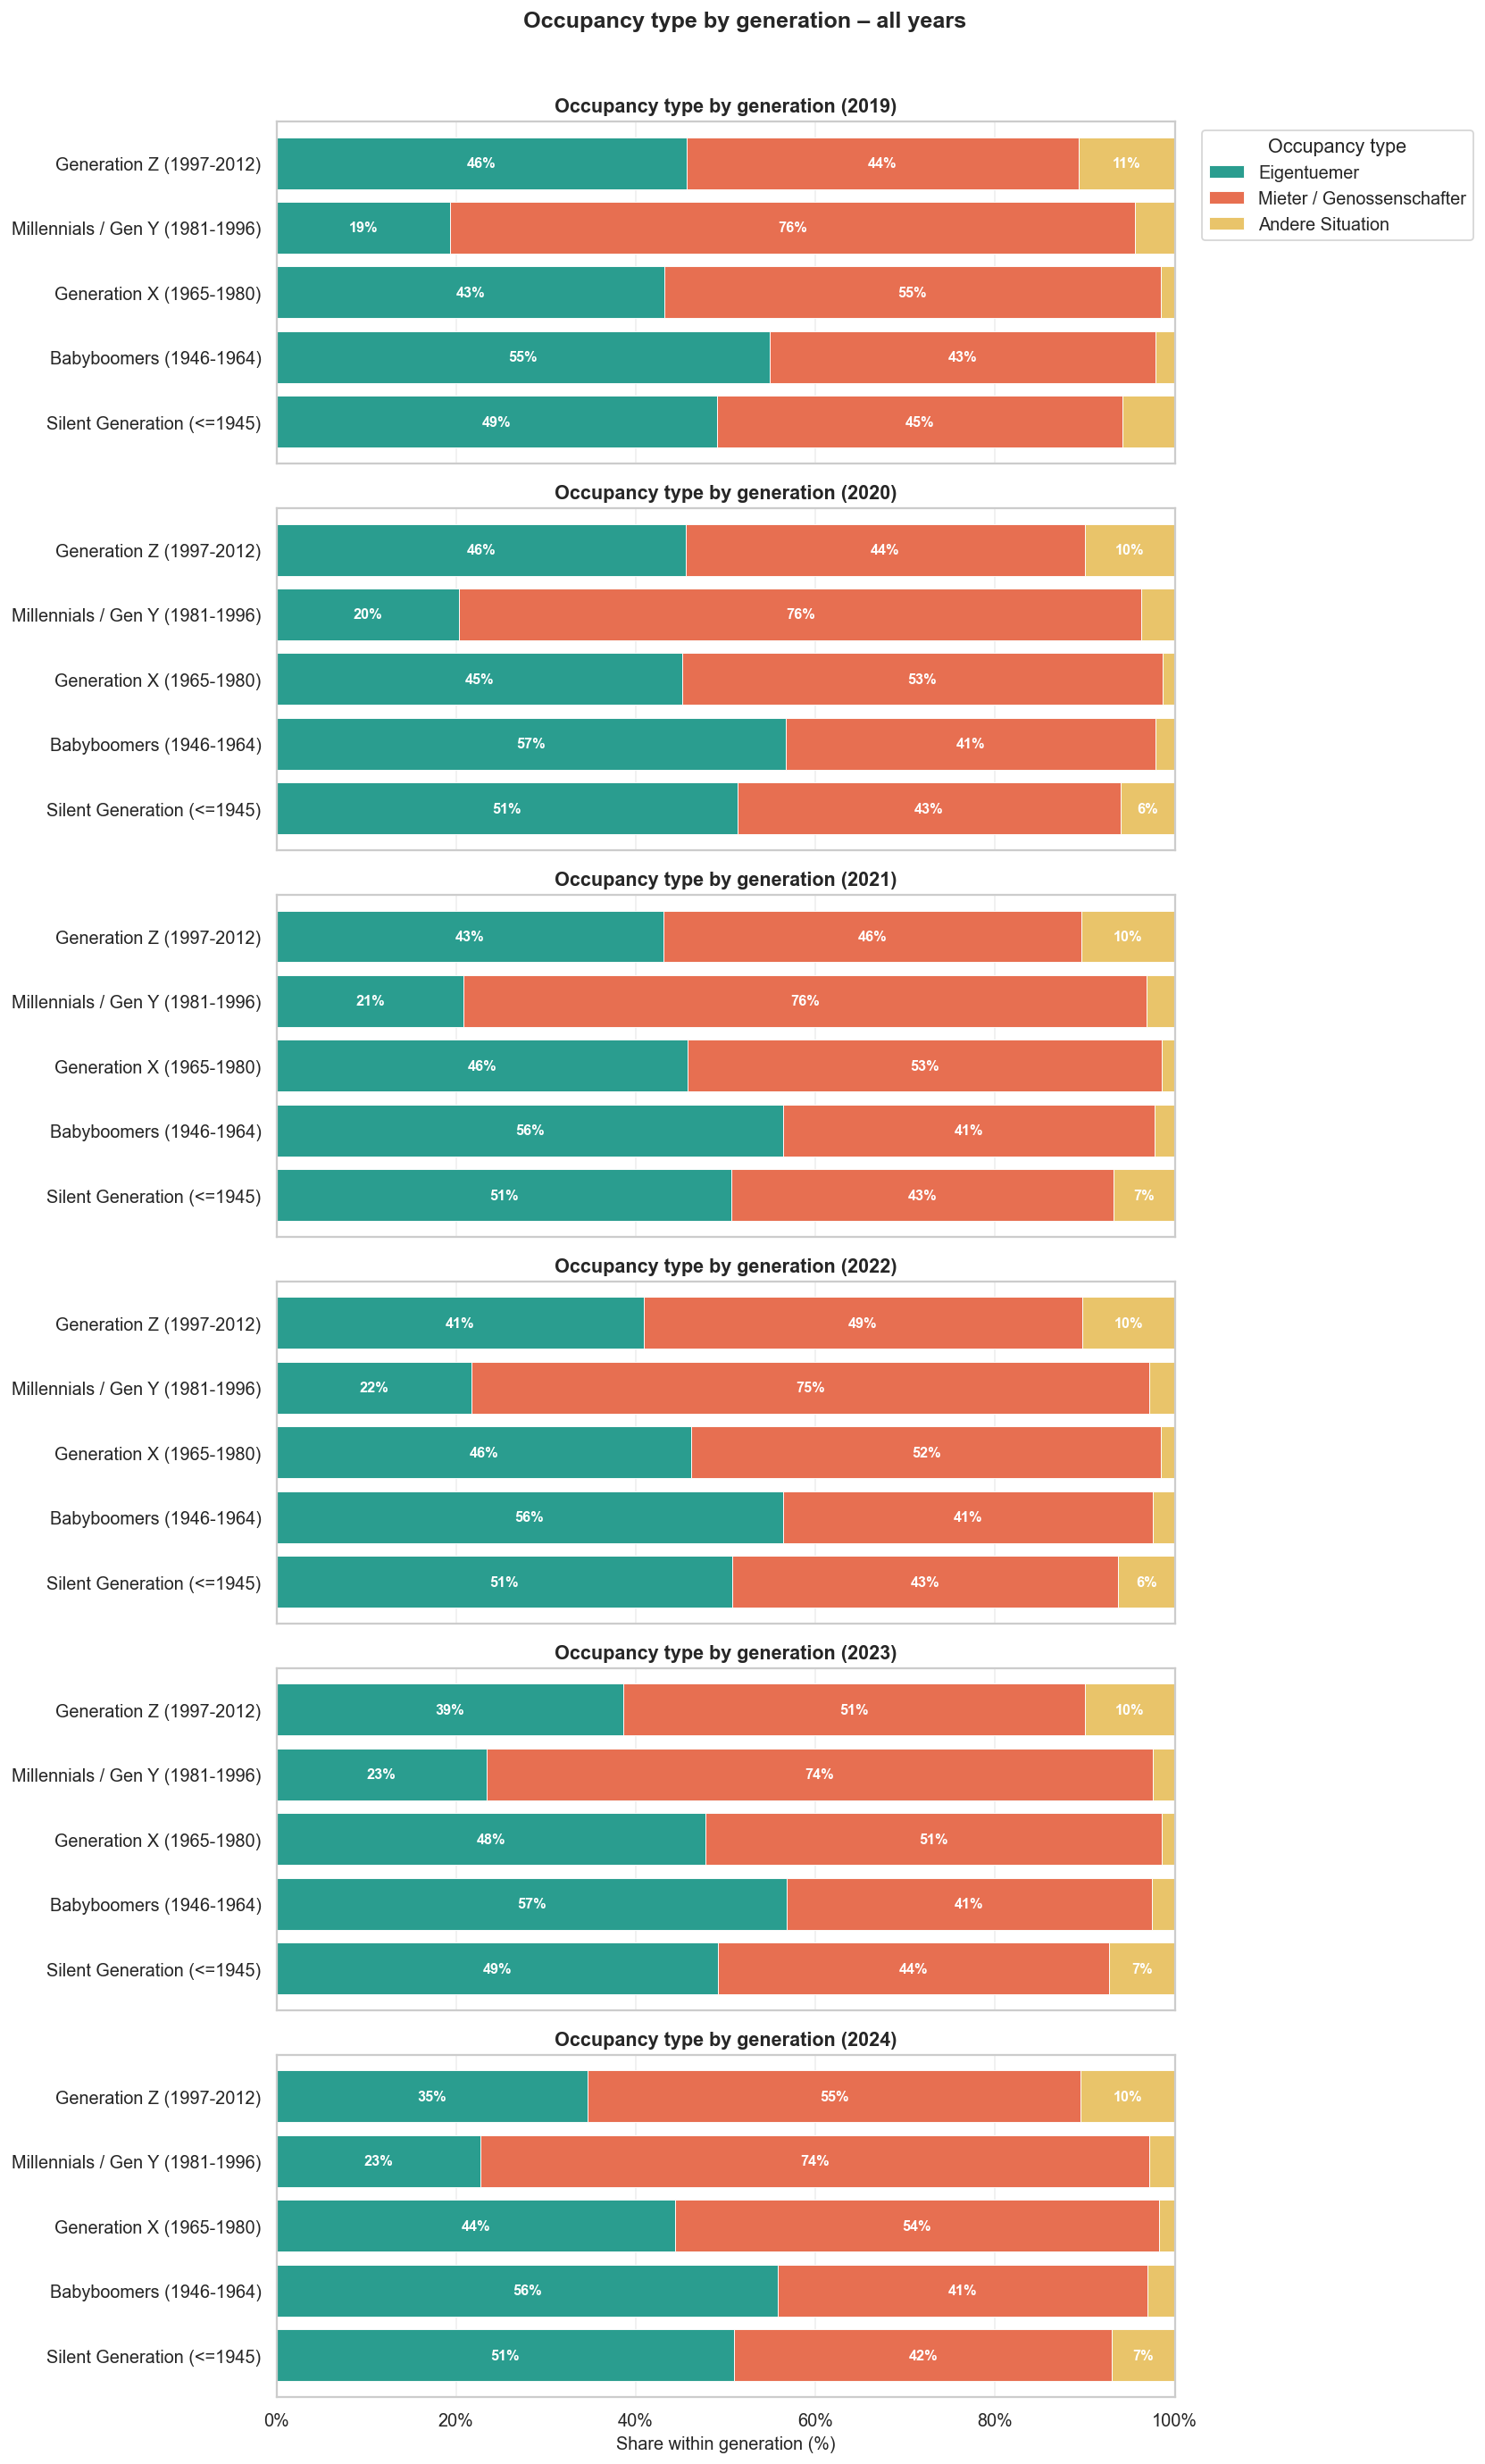

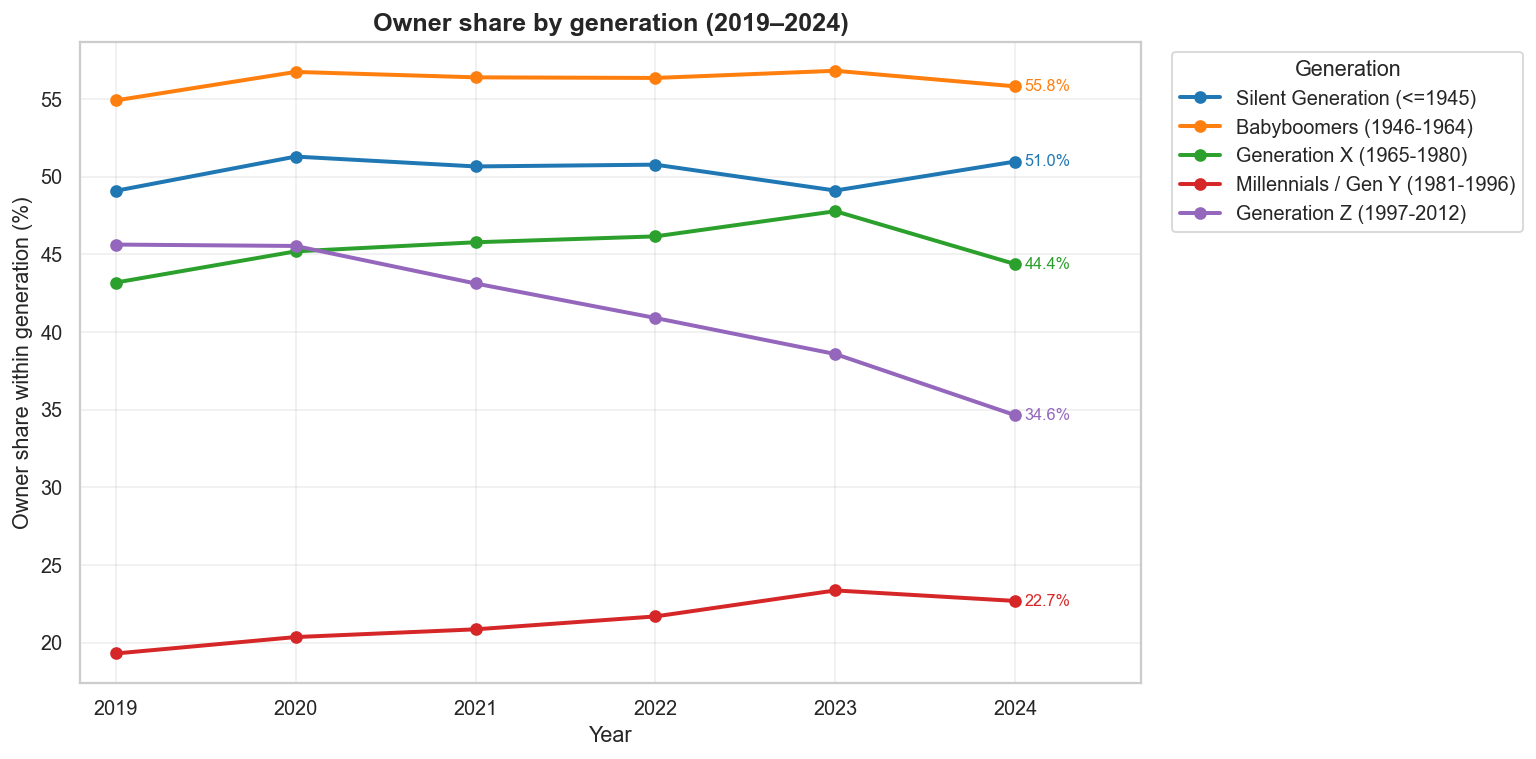

In [65]:
# ── Aggregation ────────────────────────────────────────────────────────────────
bt_base = (
    bewohnertyp
    .query("bt_label != 'total' and generation_label in @GEN_ORDER_PLOT")
    [["time_period", "generation_label", "bt_label", bt_val_col]]
    .dropna()
    .copy()
)
bt_base = bt_base[bt_base["bt_label"].isin(BT_PALETTE.keys())].copy()
bt_base["time_period"] = bt_base["time_period"].astype(int)

# ── Plot A: 100%-stacked bars (one subplot per year) ──────────────────────────
years = sorted(bt_base["time_period"].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(13, 3.5 * len(years)), sharex=True)

for ax, year in zip(np.atleast_1d(axes), years):
    agg = (
        bt_base[bt_base["time_period"] == year]
        .groupby(["generation_label", "bt_label"], observed=True)[bt_val_col]
        .sum().reset_index()
    )
    agg["share"] = agg.groupby("generation_label", observed=True)[bt_val_col].transform(
        lambda s: s / s.sum() * 100 if s.sum() > 0 else 0
    )
    pivot = (
        agg.pivot(index="generation_label", columns="bt_label", values="share")
        .reindex(GEN_ORDER_PLOT)
        .fillna(0)
        .reindex(columns=list(BT_PALETTE.keys()), fill_value=0)
)
    # Ensure every generation is scaled to exactly 100%.
    row_sum = pivot.sum(axis=1)
    pivot = pivot.div(row_sum.where(row_sum > 0, 1), axis=0) * 100

    left = np.zeros(len(pivot))
    for col in pivot.columns:
        vals = pivot[col].to_numpy()
        ax.barh(pivot.index.astype(str), vals, left=left,
                color=BT_PALETTE[col], edgecolor="white", linewidth=0.5, label=col)
        for i, v in enumerate(vals):
            if v > 6:
                ax.text(left[i] + v / 2, i, f"{v:.0f}%",
                        va="center", ha="center", fontsize=9,
                        color="white", fontweight="bold")
        left += vals

    ax.set_title(f"Occupancy type by generation ({year})", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.grid(True, axis="x", alpha=0.3)

np.atleast_1d(axes)[0].legend(title="Occupancy type", bbox_to_anchor=(1.02, 1), loc="upper left")
np.atleast_1d(axes)[-1].set_xlabel("Share within generation (%)", fontsize=11)
plt.suptitle("Occupancy type by generation – all years", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Plot B: Owner share over time ──────────────────────────────────────────────
yearly = (
    bt_base
    .groupby(["time_period", "generation_label", "bt_label"], observed=True)[bt_val_col]
    .sum().reset_index()
)
yearly["share"] = yearly.groupby(["time_period", "generation_label"], observed=True)[bt_val_col].transform(
    lambda s: s / s.sum() * 100 if s.sum() > 0 else 0
)
eigentuemer = yearly[yearly["bt_label"] == "Eigentuemer"]

fig, ax = plt.subplots(figsize=(12, 6))
for gen in GEN_ORDER_PLOT:
    sub = eigentuemer[eigentuemer["generation_label"] == gen].sort_values("time_period")
    if sub.empty:
        continue
    color = GEN_PALETTE[gen]
    ax.plot(sub["time_period"], sub["share"], marker="o", linewidth=2.2, color=color, label=gen)
    last = sub.iloc[-1]
    ax.annotate(f"{last['share']:.1f}%", xy=(last["time_period"], last["share"]),
                xytext=(5, 0), textcoords="offset points", va="center", fontsize=9, color=color)

years_all = sorted(eigentuemer["time_period"].unique())
ax.set_xticks(years_all)
ax.set_xlim(years_all[0] - 0.2, years_all[-1] + 0.7)
ax.set_title("Owner share by generation (2019–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Owner share within generation (%)", fontsize=12)
ax.legend(title="Generation", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation (Analysis 4)

**Key takeaway**
Owner occupancy is much more prevalent in older generations, while younger generations are predominantly tenants across years.

**What this means**
Tenure outcomes are strongly generation-dependent and evolve only gradually over time, reinforcing the persistence of housing inequality between cohorts.

**Caveat**
This plot is descriptive. It does not separate cohort effects from age effects, period effects, or differences in regional housing markets.

## Analysis 5 – Living Space per Person by Generation (2019–2024)

**Line plot with 95% confidence band** (based on SEM, not standard deviation).

**Expected pattern:** Silent Generation >60 m², Gen Z ~30 m² – two explanations:  
1. *Ownership effect*: owners (older generations) tend to occupy larger apartments  
2. *Empty-nest effect*: older people often live alone in formerly family-sized apartments


C:\Users\jmart\AppData\Local\Temp\ipykernel_38868\550064779.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_wf.groupby(["year", "generation_label"])[wf_area_col]


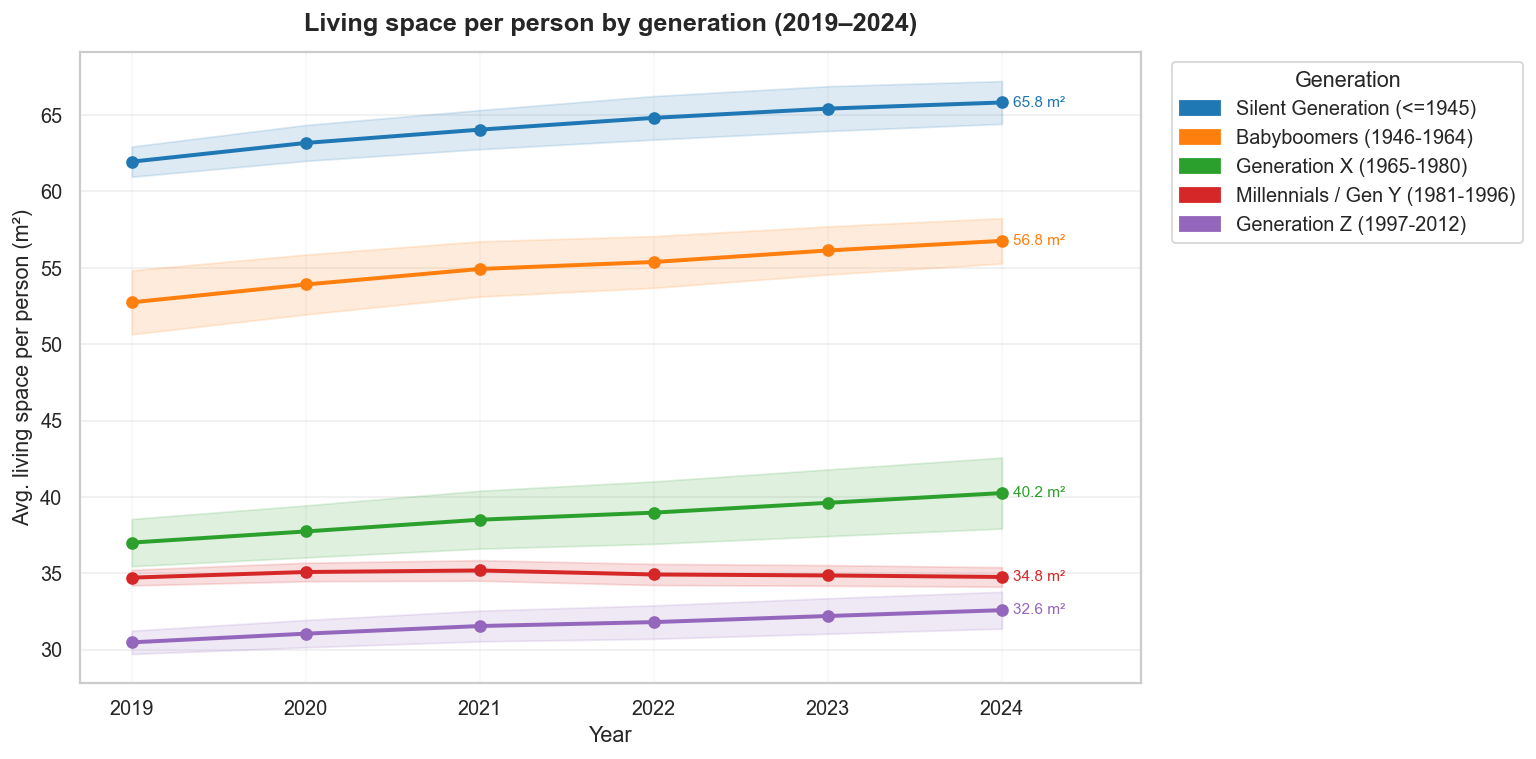

In [66]:
# ── Data ───────────────────────────────────────────────────────────────────────
df_wf = (
    wohnflaeche
    .query("generation_label in @GEN_ORDER_PLOT")
    [["time_period", "generation_label", wf_area_col]]
    .dropna()
    .assign(year=lambda x: pd.to_numeric(x["time_period"], errors="coerce").astype("Int64"))
    .dropna(subset=["year"])
)

# Mean + 95% confidence interval (SEM-based)
stats_wf = (
    df_wf.groupby(["year", "generation_label"])[wf_area_col]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
    .assign(
        ci95 = lambda x: 1.96 * x["std"] / np.sqrt(x["n"]),
        lo   = lambda x: x["mean"] - 1.96 * x["std"] / np.sqrt(x["n"]),
        hi   = lambda x: x["mean"] + 1.96 * x["std"] / np.sqrt(x["n"]),
    )
)
stats_wf["generation_label"] = pd.Categorical(stats_wf["generation_label"], categories=GEN_ORDER_PLOT, ordered=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for gen in GEN_ORDER_PLOT:
    sub = stats_wf[stats_wf["generation_label"] == gen].sort_values("year")
    if sub.empty:
        continue
    color = GEN_PALETTE[gen]
    ax.plot(sub["year"], sub["mean"], marker="o", linewidth=2.2,
            markersize=6, color=color, label=gen, zorder=3)
    ax.fill_between(sub["year"], sub["lo"], sub["hi"],
                    color=color, alpha=0.15, zorder=2)
    last = sub.iloc[-1]
    ax.annotate(f"{last['mean']:.1f} m²", xy=(last["year"], last["mean"]),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=color)

years_all = sorted(stats_wf["year"].dropna().unique())
ax.set_xticks(years_all)
ax.set_xlim(min(years_all) - 0.3, max(years_all) + 0.8)
ax.set_title("Living space per person by generation (2019–2024)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Avg. living space per person (m²)", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.grid(True, axis="x", alpha=0.15)

handles = [mpatches.Patch(color=GEN_PALETTE[g], label=g)
           for g in GEN_ORDER_PLOT if g in stats_wf["generation_label"].values]
ax.legend(handles=handles, title="Generation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Interpretation (Analysis 5)

**Key takeaway**
Average living space per person increases with age/generation, with older cohorts consistently occupying more square meters per person.

**What this means**
The observed gradient aligns with both lifecycle dynamics and ownership accumulation: older cohorts are more likely to remain in larger units with fewer household members.

**Caveat**
The confidence bands reflect sampling variability around means, but they do not identify causal mechanisms (e.g., ownership status, household composition, or income).

## Summary of EDA Findings

| Research question | Finding |
|---|---|
| Generation distribution in Switzerland | Babyboomers dominate numerically; the Silent Generation shrinks; Gen Z grows slowly |
| Cantonal homeownership rate | Clear urban-rural gradient: Geneva ~18%, Uri/Appenzell >55% |
| Occupancy type by generation | Older groups: mostly owners; younger groups: mostly tenants |
| Living space per person | Clear age gradient: Silent Gen >60 m², Gen Z ~30 m² |
| Ownership & age (canton) | Positive relationship – rural/older cantons have higher rates |

**Narrative arc:** Babyboomers and the Silent Generation built up assets – Millennials and Gen Z pay rent.
